In [290]:
#importing important libraries 
import numpy as np 
import pandas as pd 
import seaborn as sns
from sklearn. preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn .metrics import mean_squared_error, r2_score 
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt


In [291]:
#loading my dataset
df=pd.read_csv(r"C:\Users\user\Downloads\used_cars_dataset.csv")
df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,"98,000 km",NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,NaN,NaN,15.0,190000.0 km,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


PERFOMING EEXPLORATORY DATA ANALYSIS

In [292]:
#dataset information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24575 entries, 0 to 24574
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         19306 non-null  object 
 1   model         14144 non-null  object 
 2   Year          19396 non-null  float64
 3   Age           18600 non-null  float64
 4   kmDriven      18344 non-null  object 
 5   Transmission  18653 non-null  object 
 6   Owner         13949 non-null  object 
 7   FuelType      19336 non-null  object 
 8   PostedDate    18355 non-null  object 
 9   AdditionInfo  24575 non-null  object 
 10  AskPrice      24575 non-null  object 
dtypes: float64(2), object(9)
memory usage: 2.1+ MB


In [293]:
#summary statistics 
df.describe().round(2)

,Year,Age
count,19396.00,18600.00
mean,4118.98,7.68
std,3516.31,4.29
min,1900.00,0.00
25%,2015.00,5.00
50%,2018.00,7.00
75%,9999.00,10.00
max,9999.00,124.00


In [294]:
#summary statistics for object 
df.describe(include="object")

,Brand,model,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
count,19306,14144,18344,18653,13949,19336,18355,24575,24575
unique,41,403,2303,2,2,5,12,10676,1616
top,Unknown,Wagon-R,"75,000 km",Automatic,second,Petrol,Nov-24,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel","₹ 4,50,000"
freq,5125,589,351,9418,7289,5447,16323,56,355


checking for nulls 

In [295]:
#counting and summarizing nulls 
nulls = pd.DataFrame(columns=["col", "Null_count", "perc"])
tot_ = len(df)
for col in df.columns:
    null_count = df[col].isnull().sum()
    perc = (null_count * 100) / tot_
    nulls = pd.concat([nulls, pd.DataFrame({"col": [col], "Null_count": [null_count], "perc": [perc]})])

nulls = nulls.set_index("col")
nulls

C:\Users\user\AppData\Local\Temp\ipykernel_27372\2649617785.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  nulls = pd.concat([nulls, pd.DataFrame({"col": [col], "Null_count": [null_count], "perc": [perc]})])


,Null_count,perc
col,,
Brand,5269,21.440488
model,10431,42.445575
Year,5179,21.074262
Age,5975,24.313327
kmDriven,6231,25.355036
Transmission,5922,24.097660
Owner,10626,43.239064
FuelType,5239,21.318413
PostedDate,6220,25.310275


DATA PREPROCESSING 

In [296]:
#checking unique values that are under AdditionInfo
df["AdditionInfo"].unique()

array(['Honda City v teck in mint condition, valid genuine car,',
       'Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, Diesel',
       'Volkswagen Vento 2010-2013 Diesel Breeze, 2010, Diesel', ...,
       'Maruti Suzuki Wagon R LXI CNG Optional, 2022, CNG & Hybrids',
       'Bahut badhiya new condition',
       'Tata Zest  Revotron 1.2T XE, 2019, CNG & Hybrids'], dtype=object)

In [297]:
#extract Year
df["ExtractedYear"] = df["AdditionInfo"].str.extract(r'(19\d{2}|20\d{2})')
df["ExtractedYear"] = pd.to_numeric(df["ExtractedYear"], errors="coerce")
df["Year"] = df["Year"].fillna(df["ExtractedYear"])
df.drop("ExtractedYear", axis=1, inplace=True)

In [298]:
#extracting fuel 
df["ExtractedFuel"] = df["AdditionInfo"].str.extract(r'(Diesel|Petrol|CNG|Hybrid)', expand=False)
df["FuelType"] = df["FuelType"].replace("Unknown", pd.NA)
df["FuelType"] = df["FuelType"].fillna(df["ExtractedFuel"])
df.drop("ExtractedFuel", axis=1, inplace=True)

In [299]:
#extracting Brands
brands = ["Honda", "Toyota", "Volkswagen", "Maruti Suzuki", "Tata", "Hyundai", "Ford"]
pattern = "|".join(brands)
df["ExtractedBrand"] = df["AdditionInfo"].str.extract(f'({pattern})', expand=False)
df["Brand"] = df["Brand"].fillna(df["ExtractedBrand"])
df.drop("ExtractedBrand", axis=1, inplace=True)

In [300]:
#extracting Transmission 
df["ExtractedTrans"] = df["AdditionInfo"].str.extract(r'(Manual|Automatic)', expand=False)
df["Transmission"] = df["Transmission"].fillna(df["ExtractedTrans"])
df.drop("ExtractedTrans", axis=1, inplace=True)

In [301]:
df["AccidentFree"] = df["AdditionInfo"].str.contains("Accident Free", case=False).astype(int)
df["SingleOwner"] = df["AdditionInfo"].str.contains("Single Owner", case=False).astype(int)
df["WellMaintained"] = df["AdditionInfo"].str.contains("Well Maintained", case=False).astype(int)


In [302]:
current_year = 2026
df["Age"] = current_year - df["Year"]

In [303]:
#dropping the column AdditionInfo
df.drop("AdditionInfo", axis=1, inplace=True)

In [304]:
df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AskPrice,AccidentFree,SingleOwner,WellMaintained
0,Honda,NaN,2001.0,25.0,"98,000 km",NaN,NaN,NaN,Nov-24,"₹ 1,95,000",0,0,0
1,Toyota,NaN,2009.0,17.0,190000.0 km,Manual,NaN,Diesel,Jul-24,"₹ 3,75,000",0,0,0
2,Volkswagen,NaN,2010.0,16.0,NaN,Manual,first,Diesel,Nov-24,"₹ 1,84,999",0,0,0
3,Maruti Suzuki,Swift,2017.0,9.0,NaN,Manual,second,Diesel,NaN,"₹ 5,65,000",0,0,0
4,Maruti Suzuki,NaN,2019.0,7.0,NaN,Automatic,NaN,Petrol,Nov-24,"₹ 6,85,000",0,0,0


In [305]:
#creating a new combined column 
df["Brand_Model"] = df["Brand"].fillna("") + " " + df["model"].fillna("")
df["Brand_Model"] = df["Brand_Model"].str.strip()  

In [306]:
#dropping the model and Brand columns 
df.drop("model", axis=1, inplace=True)
df.drop("Brand", axis=1, inplace=True)

In [307]:
df.head()

,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AskPrice,AccidentFree,SingleOwner,WellMaintained,Brand_Model
0,2001.0,25.0,"98,000 km",NaN,NaN,NaN,Nov-24,"₹ 1,95,000",0,0,0,Honda
1,2009.0,17.0,190000.0 km,Manual,NaN,Diesel,Jul-24,"₹ 3,75,000",0,0,0,Toyota
2,2010.0,16.0,NaN,Manual,first,Diesel,Nov-24,"₹ 1,84,999",0,0,0,Volkswagen
3,2017.0,9.0,NaN,Manual,second,Diesel,NaN,"₹ 5,65,000",0,0,0,Maruti Suzuki Swift
4,2019.0,7.0,NaN,Automatic,NaN,Petrol,Nov-24,"₹ 6,85,000",0,0,0,Maruti Suzuki


In [308]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24575 entries, 0 to 24574
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            24276 non-null  float64
 1   Age             24276 non-null  float64
 2   kmDriven        18344 non-null  object 
 3   Transmission    18840 non-null  object 
 4   Owner           13949 non-null  object 
 5   FuelType        23505 non-null  object 
 6   PostedDate      18355 non-null  object 
 7   AskPrice        24575 non-null  object 
 8   AccidentFree    24575 non-null  int64  
 9   SingleOwner     24575 non-null  int64  
 10  WellMaintained  24575 non-null  int64  
 11  Brand_Model     24575 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 2.3+ MB


In [309]:
#replacing nulls with Unkown 
df["Owner"]=(df["Owner"].fillna("Unknown"))
df["Transmission"]=(df["Transmission"].fillna("Unknown"))
df["FuelType"]=(df["FuelType"].fillna("Unknown"))


In [310]:
#verifying if they are any nulls left
print("Owner:", df["Owner"].isnull().sum())
print("Transmission:", df["Transmission"].isnull().sum())
print("FuelType:", df["FuelType"].isnull().sum())


Owner: 0
Transmission: 0
FuelType: 0


In [311]:
#counting duplicated values 
df.duplicated().sum()

np.int64(9699)

In [312]:
#forward filling my year column and backfilling my postedDate column 
data=df["Year"]=(df["Year"].fillna(method="ffill"))
data=df["PostedDate"]=(df["PostedDate"].fillna(method="bfill"))
data

C:\Users\user\AppData\Local\Temp\ipykernel_27372\2352090666.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data=df["Year"]=(df["Year"].fillna(method="ffill"))
C:\Users\user\AppData\Local\Temp\ipykernel_27372\2352090666.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data=df["PostedDate"]=(df["PostedDate"].fillna(method="bfill"))


0        Nov-24
1        Jul-24
2        Nov-24
3        Nov-24
4        Nov-24
          ...  
24570    Nov-24
24571    Dec-24
24572    Nov-24
24573    Nov-24
24574    Dec-24
Name: PostedDate, Length: 24575, dtype: object

In [313]:
#cleaning and preprocessing  age and kmDriven columns 
df["kmDriven"] = df["kmDriven"].str.replace(' km', '').str.replace(',', '').astype(float) 
df["kmDriven"].fillna(df["kmDriven"].median(), inplace=True) 
df["Age"].fillna(df["Age"].median(), inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_27372\3894407046.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["kmDriven"].fillna(df["kmDriven"].median(), inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_27372\3894407046.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [314]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24575 entries, 0 to 24574
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            24575 non-null  float64
 1   Age             24575 non-null  float64
 2   kmDriven        24575 non-null  float64
 3   Transmission    24575 non-null  object 
 4   Owner           24575 non-null  object 
 5   FuelType        24575 non-null  object 
 6   PostedDate      24575 non-null  object 
 7   AskPrice        24575 non-null  object 
 8   AccidentFree    24575 non-null  int64  
 9   SingleOwner     24575 non-null  int64  
 10  WellMaintained  24575 non-null  int64  
 11  Brand_Model     24575 non-null  object 
dtypes: float64(3), int64(3), object(6)
memory usage: 2.3+ MB


<Axes: ylabel='kmDriven'>

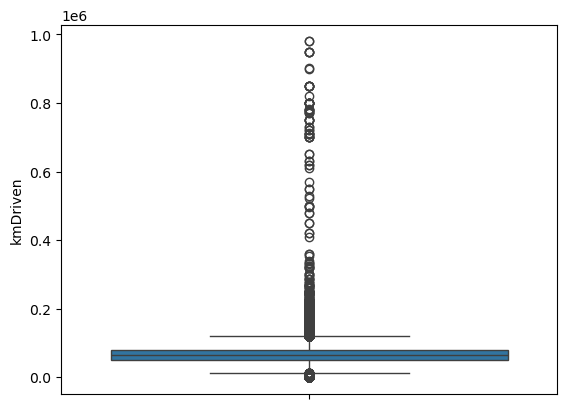

In [315]:
#checking for outliers 
sns.boxplot(df["kmDriven"])

In [316]:
df.loc[df["Age"]>=40]

,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AskPrice,AccidentFree,SingleOwner,WellMaintained,Brand_Model
7404,1986.0,40.0,68000.0,Unknown,second,Petrol,Nov-24,"₹ 1,20,000",0,0,0,Maruti Suzuki
16986,1986.0,40.0,68000.0,Unknown,second,Petrol,Nov-24,"₹ 1,20,000",0,0,0,Maruti Suzuki
20842,1931.0,95.0,88000.0,Manual,first,hybrid,Nov-24,"₹ 3,49,000",0,0,0,Maruti Suzuki Wagon-R
20974,1900.0,126.0,40000.0,Automatic,second,hybrid,Dec-24,"₹ 4,40,000",0,0,0,Renault Triber
21040,1978.0,48.0,100000.0,Manual,second,Diesel,Nov-24,"₹ 2,00,000",0,0,0,Mahindra Jeep
22127,1920.0,106.0,60000.0,Manual,first,Petrol,Nov-24,"₹ 5,19,000",0,0,0,Maruti Suzuki Swift


concerns:




In [317]:
#checking how many unique values I have on this columns 
cols=[ "Transmission", "Owner", "FuelType" ]
for col in cols:
    print( col ,"\t", df[col].nunique())

Transmission 	 3
Owner 	 3
FuelType 	 7


In [318]:
#one-hot encoding Transmisssion, owner  and fuelType columns into integers 
df=pd.get_dummies(df, columns= ["Transmission", "Owner", "FuelType"], dtype=int)
df.head()
              

,Year,Age,kmDriven,PostedDate,AskPrice,AccidentFree,SingleOwner,WellMaintained,Brand_Model,Transmission_Automatic,...,Owner_Unknown,Owner_first,Owner_second,FuelType_CNG,FuelType_Diesel,FuelType_Hybrid,FuelType_Hybrid/CNG,FuelType_Petrol,FuelType_Unknown,FuelType_hybrid
0,2001.0,25.0,98000.0,Nov-24,"₹ 1,95,000",0,0,0,Honda,0,...,1,0,0,0,0,0,0,0,1,0
1,2009.0,17.0,190000.0,Jul-24,"₹ 3,75,000",0,0,0,Toyota,0,...,1,0,0,0,1,0,0,0,0,0
2,2010.0,16.0,65200.0,Nov-24,"₹ 1,84,999",0,0,0,Volkswagen,0,...,0,1,0,0,1,0,0,0,0,0
3,2017.0,9.0,65200.0,Nov-24,"₹ 5,65,000",0,0,0,Maruti Suzuki Swift,0,...,0,0,1,0,1,0,0,0,0,0
4,2019.0,7.0,65200.0,Nov-24,"₹ 6,85,000",0,0,0,Maruti Suzuki,1,...,1,0,0,0,0,0,0,1,0,0


In [319]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24575 entries, 0 to 24574
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    24575 non-null  float64
 1   Age                     24575 non-null  float64
 2   kmDriven                24575 non-null  float64
 3   PostedDate              24575 non-null  object 
 4   AskPrice                24575 non-null  object 
 5   AccidentFree            24575 non-null  int64  
 6   SingleOwner             24575 non-null  int64  
 7   WellMaintained          24575 non-null  int64  
 8   Brand_Model             24575 non-null  object 
 9   Transmission_Automatic  24575 non-null  int64  
 10  Transmission_Manual     24575 non-null  int64  
 11  Transmission_Unknown    24575 non-null  int64  
 12  Owner_Unknown           24575 non-null  int64  
 13  Owner_first             24575 non-null  int64  
 14  Owner_second            24575 non-null

In [320]:
#droping Transmission_Unknown, owner_Unknown, FuelType_Unknown and  Year columns 
df=df.drop(["Transmission_Unknown"], axis=1)
df=df.drop(["Owner_Unknown"], axis=1)
df=df.drop(["FuelType_Unknown"], axis=1)
df=df.drop(["Year"], axis=1)

In [321]:
#convecting the AskPrice column to a float 
df["AskPrice"] = df["AskPrice"].str.replace('₹', '').str.replace(',', '').str.strip()
df["AskPrice"] = df["AskPrice"].astype(float)


In [322]:
#Keeping only top frequent Brand_Model combinations and group the rest as Other
brand_model_counts = df["Brand_Model"].value_counts()
top_brand_models = brand_model_counts[brand_model_counts > 20].index
df["Brand_Model"] = df["Brand_Model"].apply(lambda x: x if x in top_brand_models else "Other")

In [323]:
#one-hot encoding Brand_Model column 
df=pd.get_dummies(df, columns= ["Brand_Model"], dtype=int)
df.head()
              

,Age,kmDriven,PostedDate,AskPrice,AccidentFree,SingleOwner,WellMaintained,Transmission_Automatic,Transmission_Manual,Owner_first,...,Brand_Model_Unknown Wagon-R-1-0,Brand_Model_Unknown XUV500,Brand_Model_Unknown i10,Brand_Model_Unknown i20,Brand_Model_Volkswagen,Brand_Model_Volkswagen Ameo,Brand_Model_Volkswagen Polo,Brand_Model_Volkswagen VentoTest,Brand_Model_Volvo,Brand_Model_XUV500
0,25.0,98000.0,Nov-24,195000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,17.0,190000.0,Jul-24,375000.0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,16.0,65200.0,Nov-24,184999.0,0,0,0,0,1,1,...,0,0,0,0,1,0,0,0,0,0
3,9.0,65200.0,Nov-24,565000.0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,7.0,65200.0,Nov-24,685000.0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [324]:
#date feature engineering
df["PostedDate"] = pd.to_datetime(df["PostedDate"], format="%b-%y", errors="coerce")
df["DaysSincePosting"] = (pd.Timestamp.today() - df["PostedDate"]).dt.days
df = df.drop("PostedDate", axis=1)

In [325]:
df.head()

,Age,kmDriven,AskPrice,AccidentFree,SingleOwner,WellMaintained,Transmission_Automatic,Transmission_Manual,Owner_first,Owner_second,...,Brand_Model_Unknown XUV500,Brand_Model_Unknown i10,Brand_Model_Unknown i20,Brand_Model_Volkswagen,Brand_Model_Volkswagen Ameo,Brand_Model_Volkswagen Polo,Brand_Model_Volkswagen VentoTest,Brand_Model_Volvo,Brand_Model_XUV500,DaysSincePosting
0,25.0,98000.0,195000.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,502
1,17.0,190000.0,375000.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,625
2,16.0,65200.0,184999.0,0,0,0,0,1,1,0,...,0,0,0,1,0,0,0,0,0,502
3,9.0,65200.0,565000.0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,502
4,7.0,65200.0,685000.0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,502


In [326]:
#scaling numeric features 
scaler = StandardScaler()
df[["Age", "kmDriven", "DaysSincePosting"]] = scaler.fit_transform(df[["Age", "kmDriven", "DaysSincePosting"]])

In [327]:
df.head()

,Age,kmDriven,AskPrice,AccidentFree,SingleOwner,WellMaintained,Transmission_Automatic,Transmission_Manual,Owner_first,Owner_second,...,Brand_Model_Unknown XUV500,Brand_Model_Unknown i10,Brand_Model_Unknown i20,Brand_Model_Volkswagen,Brand_Model_Volkswagen Ameo,Brand_Model_Volkswagen Polo,Brand_Model_Volkswagen VentoTest,Brand_Model_Volvo,Brand_Model_XUV500,DaysSincePosting
0,0.517034,0.572945,195000.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-0.147821
1,0.514564,2.430725,375000.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,6.776634
2,0.514255,-0.089394,184999.0,0,0,0,0,1,1,0,...,0,0,0,1,0,0,0,0,0,-0.147821
3,0.512094,-0.089394,565000.0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,-0.147821
4,0.511477,-0.089394,685000.0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,-0.147821


In [328]:
cor=df.corr()
cor.head()

,Age,kmDriven,AskPrice,AccidentFree,SingleOwner,WellMaintained,Transmission_Automatic,Transmission_Manual,Owner_first,Owner_second,...,Brand_Model_Unknown XUV500,Brand_Model_Unknown i10,Brand_Model_Unknown i20,Brand_Model_Volkswagen,Brand_Model_Volkswagen Ameo,Brand_Model_Volkswagen Polo,Brand_Model_Volkswagen VentoTest,Brand_Model_Volvo,Brand_Model_XUV500,DaysSincePosting
Age,1.000000,0.002174,-0.019818,NaN,0.002239,-0.009111,0.014743,0.000839,0.018362,0.048408,...,-0.004178,0.000009,-0.019097,-0.002801,-0.002535,0.009647,0.002532,-0.009308,-0.011507,-0.055305
kmDriven,0.002174,1.000000,-0.123608,NaN,0.000676,0.035153,-0.057592,0.058982,-0.079356,0.087115,...,0.007553,-0.000782,0.020358,0.003535,0.003143,-0.001793,0.009280,0.015484,0.004830,-0.009199
AskPrice,-0.019818,-0.123608,1.000000,NaN,-0.007930,-0.044645,0.219297,-0.232424,0.061843,-0.074929,...,-0.005193,-0.020888,-0.013647,-0.023200,-0.010997,-0.021875,-0.020732,0.039116,-0.003540,0.028447
AccidentFree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SingleOwner,0.002239,0.000676,-0.007930,NaN,1.000000,-0.004873,-0.006342,0.009426,0.019675,-0.014353,...,-0.000892,-0.000978,-0.000892,-0.002308,-0.000705,-0.001834,-0.001370,-0.000798,-0.000936,-0.003267


In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24575 entries, 0 to 24574
Columns: 188 entries, Age to DaysSincePosting
dtypes: float64(4), int64(184)
memory usage: 35.2 MB


In [331]:
#importing train_test_split model
from sklearn.model_selection import train_test_split

SPLITING MY DATASET AND TRAINING USING DIFFERENT ALGORITHMNS 

In [332]:
X= df.drop("AskPrice", axis=1)
Y= df["AskPrice"]


In [280]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2, random_state=42)

In [281]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

TRAINING MODEL1 

In [282]:
model1 = LinearRegression()

In [283]:
model1.fit(X_train, Y_train)

LinearRegression()

In [284]:
y_pred=model1.predict (X_test)

In [285]:
from math import sqrt 

mse_1 = mean_squared_error(Y_test, y_pred)
rmse_1 = sqrt(mse_1)
r2_1 = r2_score(Y_test, y_pred)
print (f"RMSE = {rmse_1:.3f}")
print (F"R**2 ={r2_1:.3f}")

RMSE = 1370889.167
R**2 =0.245


MODEL2

In [286]:
model2= RandomForestRegressor(random_state=42)

In [287]:
model2.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

In [288]:
y_pred= model2.predict(X_test)

In [289]:
from math import sqrt 

mse_2 = mean_squared_error(Y_test, y_pred)
rmse_2 = sqrt(mse_2)
r2_2 = r2_score(Y_test, y_pred)
print (f"RMSE = {rmse_2:.3f}")
print (F"R**2 ={r2_2:.3f}")

RMSE = 792988.505
R**2 =0.747


MODEL3

In [290]:
model3=Ridge(random_state=42)

In [291]:
model3.fit(X_train,Y_train)

Ridge(random_state=42)

In [292]:
y_pred=model3.predict(X_test)

In [293]:
from math import sqrt 

mse_3 = mean_squared_error(Y_test, y_pred)
rmse_3 = sqrt(mse_3)
r2_3 = r2_score(Y_test, y_pred)
print (f"RMSE = {rmse_3:.3f}")
print (F"R**2 ={r2_3:.3f}")

RMSE = 1370888.078
R**2 =0.245


MODEL4

In [294]:
model4=Lasso(random_state=42)

In [295]:
model4.fit(X_train,Y_train)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.450e+15, tolerance: 5.189e+12
  model = cd_fast.enet_coordinate_descent(


Lasso(random_state=42)

In [296]:
y_pred=model4.predict(X_test)

In [297]:
from math import sqrt 

mse_4 = mean_squared_error(Y_test, y_pred)
rmse_4 = sqrt(mse_4)
r2_4 = r2_score(Y_test, y_pred)
print (f"RMSE = {rmse_4:.3f}")
print (F"R**2 ={r2_4:.3f}")

RMSE = 1370888.908
R**2 =0.245


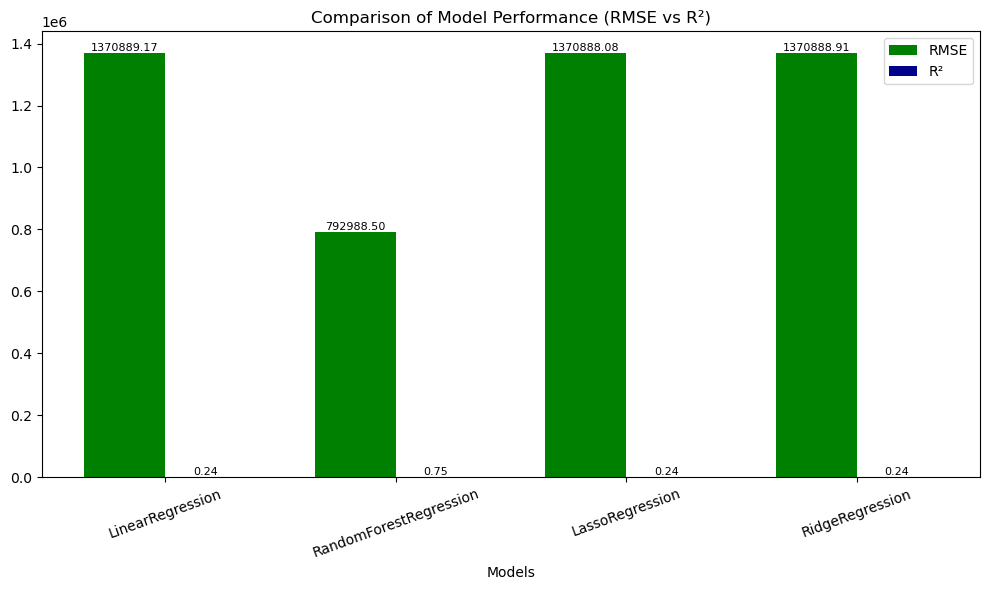

In [298]:
#creating a model comparison visualization
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

models = ["LinearRegression", "RandomForestRegression", 
          "LassoRegression", "RidgeRegression"]

rmse_scores = [rmse_1, rmse_2, rmse_3, rmse_4]
r2_scores   = [r2_1, r2_2, r2_3, r2_4]

fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.35

bar1 = ax1.bar(x - width/2, rmse_scores, width, label="RMSE", color="green")
bar2 = ax1.bar(x + width/2, r2_scores, width, label="R²", color="darkblue")

ax1.set_xlabel("Models")
ax1.set_title("Comparison of Model Performance (RMSE vs R²)")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=20)
ax1.legend()

for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

vedict:

SO MODEL 2 TURN TO BE THE BETTER MODEL DUE TO :

LOWEST RMSE OF =792988.505
         
HIGHERST R**2 OF =0.747

FINE TUNE 

In [281]:
param_grid={"n_estimators":[100, 200, 300, 400]}

In [282]:
from sklearn.model_selection import RandomizedSearchCV

In [283]:
model = RandomForestRegressor()

rs=RandomizedSearchCV(model, param_grid, cv=5, n_iter=50)

rs.fit(X_train, Y_train)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=50. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=50,
                   param_distributions={'n_estimators': [100, 200, 300, 400]})

In [284]:
best_params = rs.best_params_

In [285]:
model_best= RandomForestRegressor(**best_params, random_state=42)

In [286]:
model_best.fit(X_train, Y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [287]:
y_pred = model_best

In [288]:
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

y_pred = model_best.predict(X_test)
mse_best = mean_squared_error(Y_test, y_pred)
rmse_best = sqrt(mse_best)
r2_best = r2_score(Y_test, y_pred)

print(f"RMSE = {rmse_best:.3f}")
print(f"R**2 = {r2_best:.3f}")

RMSE = 791452.391
R**2 = 0.748


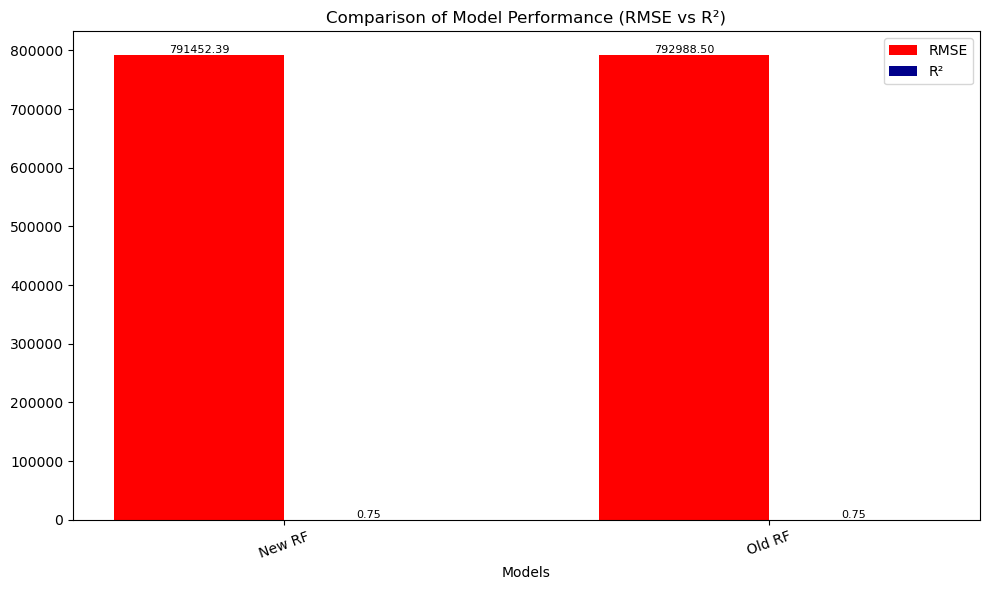

In [289]:
#compare two versions New RF and OLD RF 
models = ["New RF", "Old RF"]

rmse_scores = [rmse_best, rmse_2]
r2_scores   = [r2_best, r2_2]

fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.35

bar1 = ax1.bar(x - width/2, rmse_scores, width, label="RMSE", color="red")
bar2 = ax1.bar(x + width/2, r2_scores, width, label="R²", color="darkblue")

ax1.set_xlabel("Models")
ax1.set_title("Comparison of Model Performance (RMSE vs R²)")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=20)
ax1.legend()

for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()